# CS 5785 Homework 2 — Programming Exercise 1

Linear regression on $Y=\alpha+\beta X+\epsilon$ with $\alpha=20$, $\beta=0.5$, $X\sim\mathcal N(168,30^2)$, $\epsilon\sim\mathcal N(0,20^2)$. Each $n$ is an independent sample. The population $R^2$ limit derived in the write-up is $0.36$.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

SEED = 5785
ALPHA, BETA = 20.0, 0.5
MU_X, SD_X, SD_EPS = 168.0, 30.0, 20.0
VAR_Y = (BETA ** 2) * (SD_X ** 2) + SD_EPS ** 2
R2_LIMIT = 1.0 - (SD_EPS ** 2) / VAR_Y
print('Var(Y) =', VAR_Y, ' R2 limit =', R2_LIMIT)

rng = np.random.default_rng(SEED)
rows = []
for n in [10 ** k for k in range(2, 7)]:
    x = rng.normal(MU_X, SD_X, size=(n, 1))
    eps = rng.normal(0.0, SD_EPS, size=(n, 1))
    y = ALPHA + BETA * x + eps
    reg = LinearRegression().fit(x, y.ravel())
    row = {
        'n': n,
        'alpha_hat': float(reg.intercept_),
        'beta_hat': float(reg.coef_[0]),
        'r2': float(reg.score(x, y.ravel())),
    }
    rows.append(row)
    print(f"n={n:<8d} alpha={row['alpha_hat']:.6f} "
          f"beta={row['beta_hat']:.6f} R2={row['r2']:.6f}")


Var(Y) = 625.0  R2 limit = 0.36
n=100      alpha=6.811091 beta=0.551040 R2=0.434427
n=1000     alpha=13.515877 beta=0.533091 R2=0.362546
n=10000    alpha=20.549934 beta=0.496641 R2=0.355174
n=100000   alpha=20.085025 beta=0.499001 R2=0.358380


n=1000000  alpha=19.800149 beta=0.501345 R2=0.361608


The slope approaches $0.5$ quickly. The intercept approaches $20$ more slowly because $X$ lives near $168$, so $\hat\alpha$ is an extrapolation to $x=0$. Training $R^2$ settles at $0.36$, not at $0$.

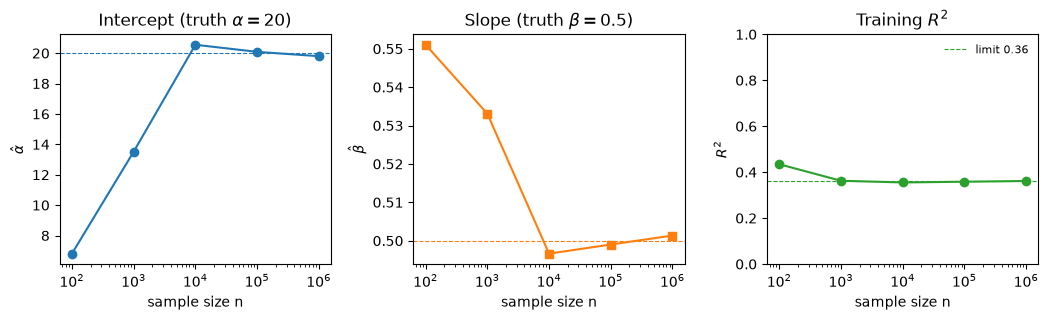

In [2]:
ns = [r['n'] for r in rows]
fig, axes = plt.subplots(1, 3, figsize=(10.6, 3.3))
axes[0].plot(ns, [r['alpha_hat'] for r in rows], 'o-', color='C0')
axes[0].axhline(ALPHA, color='C0', ls='--', lw=0.8)
axes[0].set_xscale('log')
axes[0].set_xlabel('sample size n')
axes[0].set_ylabel(r'$\hat\alpha$')
axes[0].set_title(r'Intercept (truth $\alpha=20$)')
axes[1].plot(ns, [r['beta_hat'] for r in rows], 's-', color='C1')
axes[1].axhline(BETA, color='C1', ls='--', lw=0.8)
axes[1].set_xscale('log')
axes[1].set_xlabel('sample size n')
axes[1].set_ylabel(r'$\hat\beta$')
axes[1].set_title(r'Slope (truth $\beta=0.5$)')
axes[2].plot(ns, [r['r2'] for r in rows], 'o-', color='C2')
axes[2].axhline(R2_LIMIT, color='C2', ls='--', lw=0.8, label=f'limit {R2_LIMIT:.2f}')
axes[2].set_xscale('log')
axes[2].set_xlabel('sample size n')
axes[2].set_ylabel(r'$R^2$')
axes[2].set_ylim(0, 1)
axes[2].set_title(r'Training $R^2$')
axes[2].legend(frameon=False, fontsize=8)
fig.tight_layout()
fig_dir = Path('..') / 'figures' if not (Path('figures')).exists() else Path('figures')
if (Path('..') / 'figures').exists():
    fig_dir = Path('..') / 'figures'
fig_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(fig_dir / 'part1_convergence.png', dpi=150)
plt.show()
